In [1]:
from datasets import load_dataset

ds = load_dataset("hammer888/interior_style_dataset")

c:\Users\m62\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 7233
    })
})

In [3]:
example_sample = ds['train'][0]
example_sample

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1500x1000>,
 'text': 'A photo of Modern style interior design'}

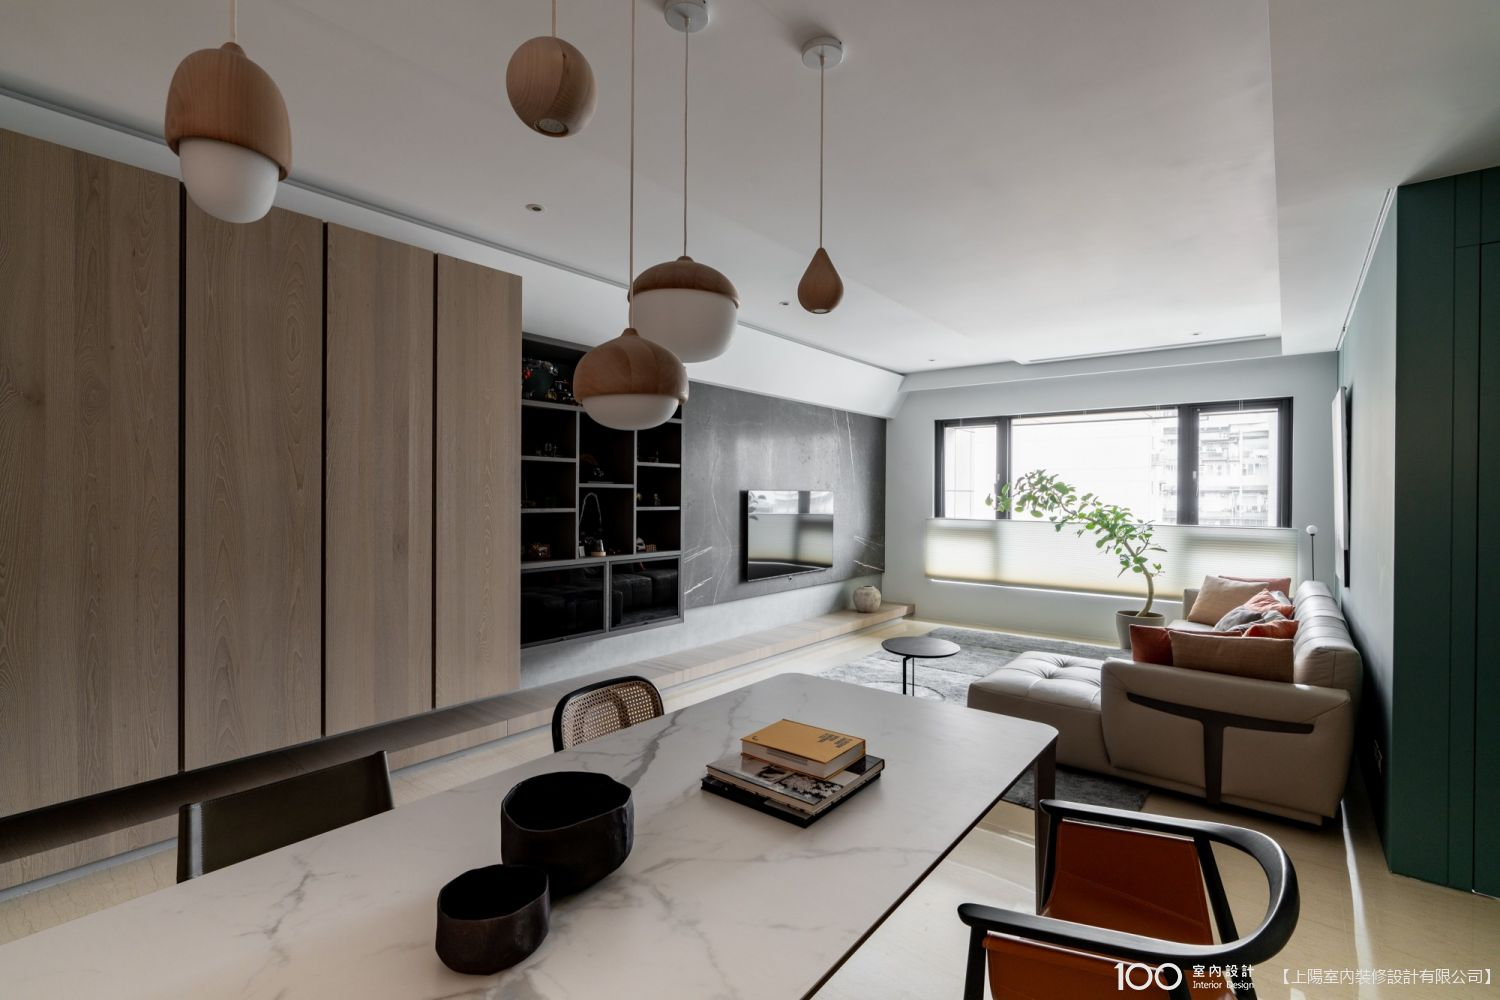

In [4]:
example_sample['image']

In [5]:
SYSTEM_PROMPT = '''You are an expert in extracting the items in the room that includes furniture and any items used as decoration aswell.
 your job is to look at the images and give back a list of strings with all the items from the images'''

In [6]:
USER_PROMPT = '''You have to extract all the furniture and decorative items from the image and return a structred format, JSON back to me.
If the image does not contain any furniture or decorative item then return a empty list. Do not give me paragraphs of text just list out the items in json format

Only return the data in the below valid JSON format

```json

{
  number_of_items: int, # number of items in the image, 0 if none
  items: {
    furniture:[] #list[str] - all the furniture items in the image
    decoration:[] #list[str] - all the decoration items in the image
  }, # list of items in the image
  estimated_cost: float, # estimated cost of the items in the image round it off and give value in USD.


}
```

'''

### Below is for fine tuning purpose 

In [7]:
# Create helper function to map our input/output samples to conversational format

def format_data(sample):
  return {
      'message':[


          #Message 0 : system prompt

          {
              'role':'system',
              'content':[{'type':'text','text':SYSTEM_PROMPT}]
          },

          #Message 1 : user prompt

          {
              'role':'user',
              'content':[
                  {
                      'type':'text',
                      'content':USER_PROMPT
                  },
                  {
                      'type':'image',
                      'image':sample['image']
                  }
              ]
          },

          #Message 2 : Models task

          {
              'role':'assistant',
              'content':[{'type':'text','text':'look at the image and return the valid json Output'}]
          }
      ]

  }

In [8]:
import pprint

format_sample = format_data(example_sample)
pprint.pprint(format_sample)

{'message': [{'content': [{'text': 'You are an expert in extracting the items '
                                   'in the room that includes furniture and '
                                   'any items used as decoration aswell.\n'
                                   ' your job is to look at the images and '
                                   'give back a list of strings with all the '
                                   'items from the images',
                           'type': 'text'}],
              'role': 'system'},
             {'content': [{'content': 'You have to extract all the furniture '
                                      'and decorative items from the image and '
                                      'return a structred format, JSON back to '
                                      'me.\n'
                                      'If the image does not contain any '
                                      'furniture or decorative item then '
                                   

### Ollama cannot work with PIL, it need jpg or Bytes. Converting PIL to Bytes

In [15]:
from io import BytesIO

def pil_to_bytes(img):
    buffer = BytesIO()
    img.save(buffer, format="JPEG")
    return buffer.getvalue()

In [17]:
import ollama



def get_from_qwen(image_path):


    image_bytes = pil_to_bytes(image_path)

    
    response = ollama.chat(
        model='qwen3-vl:8b',
        messages=[
            {
                "role": "system",
                "content": SYSTEM_PROMPT
            },
            {
                "role": "user",
                "content":USER_PROMPT,
                "images": [image_bytes]
            }
        ],
        options={
            "temperature": 0
        }
    )

    return response['message']['content']

### Running the loop with entire dataset may take upto 20-22 hrs

#### To reduce time:- 
        1. reduce dataset size
        2. temp=0
        3. parallel processing
        4. reduce image size

In [10]:
import huggingface_hub as hf_hub

model_id = "OpenVINO/qwen3-8b-int4-ov"
model_path = "../models/qwen3-8b-int4-ov"

hf_hub.snapshot_download(model_id, local_dir=model_path)


Fetching 18 files: 100%|██████████| 18/18 [00:42<00:00,  2.38s/it]


'C:\\Users\\m62\\Desktop\\RoomMind\\models\\qwen3-8b-int4-ov'

In [12]:
import openvino_genai
from PIL import Image

# Initialize the pipeline to use your NPU (or "GPU" for integrated graphics)
# This is where the 11-minute wait disappears!
pipe = openvino_genai.VLMPipeline("../models/qwen3-8b-int4-ov", "NPU") 

def get_from_qwen_ov(image_path):
    # OpenVINO GenAI handles the image and prompt directly
    # We use a standard chat template format
    prompt = f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n<|im_start|>user\n{USER_PROMPT}<|im_end|>\n<|im_start|>assistant\n"
    
    # Load image as PIL
    image = Image.open(image_path).convert("RGB")
    
    # Generate - this should now take seconds, not minutes
    output = pipe.generate(prompt, image=image, max_new_tokens=512)
    return output.texts[0]

RuntimeError: Exception from src\inference\src\cpp\core.cpp:85:
Check 'util::directory_exists(path) || util::file_exists(path)' failed at src\frontends\common\src\frontend.cpp:116:
FrontEnd API failed with GeneralFailure:
ir: Could not open the file: "../models/qwen3-8b-int4-ov\openvino_language_model.xml"



### Trying out OpenVINO to utilize the NPU

In [ ]:
import openvino_genai
from PIL import Image

# 1. Initialize the pipe ONCE outside the function to save memory/time
# Use "GPU" for your Intel Graphics or "NPU" for the AI accelerator
device = "GPU" 
model_path = "path_to_your_openvino_qwen_model" # You must convert/download the OV version
pipe = openvino_genai.VLMPipeline(model_path, device)

def get_from_qwen_ov(pil_image):
    # OpenVINO GenAI typically uses a combined prompt format for VLMs
    # We combine System and User prompts for the chat template
    full_prompt = f"<|im_start|>system\n{SYSTEM_PROMPT}<|im_end|>\n<|im_start|>user\n{USER_PROMPT}<|im_end|>\n<|im_start|>assistant\n"
    
    # Generate output
    # OpenVINO GenAI takes the PIL image directly
    output = pipe.generate(full_prompt, image=pil_image, max_new_tokens=512)
    
    return output.texts[0]

### using a subset of the dataset

In [ ]:
import json
from tqdm import tqdm

results = []

subset_ds = ds['train'].select(range(1000))

for a_image in tqdm(subset_ds):
    output = get_from_qwen(a_image['image'])
    
    try:
        parsed = json.loads(output)
    except:
        parsed = None

    results.append({
        "output": parsed
    })

  0%|          | 0/1000 [00:00<?, ?it/s]

In [ ]:
with open("labels.json", "w") as f:
    json.dump(results, f, indent=2)

In [ ]:
output = get_from_qwen(example_sample['image'])
print(output)

{
  "number_of_items": 12,
  "items": {
    "furniture": [
      "dining table",
      "dining chairs",
      "sofa",
      "chaise lounge",
      "side table",
      "large wooden cabinet"
    ],
    "decoration": [
      "plant",
      "books",
      "black bowls",
      "cushions",
      "rug",
      "tv"
    ]
  },
  "estimated_cost": 7370.0
}
